# Demo Embedding Code

In [1]:
from src.embeddings import sample_landmarks_random, farthest_point_sampling, dist_to_landmarks
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import src.densities as densities
from src.manifolds import get as get_manifold

In [2]:
# This cell is optional - the main demo runs in the cell below.
# You can uncomment to experiment with different landmark counts.

# Ms = [8, 16, 32, 64, 128, 256]
# M_max = max(Ms)
# 
# key, kL = jax.random.split(key)
# landmarks_max = sample_landmarks_random(base, kL, M_max)

In [3]:
# Helper plotting functions are defined in the main cell below.
# This cell is kept for reference but not needed.

In [4]:
def coverage_radius(manifold, X_val, landmarks):
    """Compute coverage radius: r_M = max_x min_j d(x, l_j)"""
    D = dist_to_landmarks(manifold, X_val, landmarks)  # (N, M)
    return float(jnp.max(jnp.min(D, axis=1)))

LANDMARK EMBEDDING DIAGNOSTICS

Manifold: S² (2-sphere)
Held-out validation set: |X_val| = 2048
Landmark counts M: [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
Near-collision tolerance ε: 0.001

Computing s_M, ρ_M(ε), R_M for each M...

Figure saved to: embedding_diagnostics.pdf (6.75in wide)


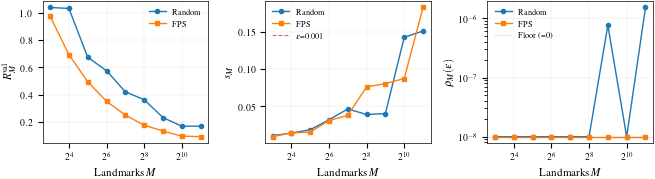


EMBEDDING DIAGNOSTICS SUMMARY

Selection criterion: s_M > ε = 0.001 and ρ_M(ε) ≈ 0

Random Landmarks:
   M      R_M  s_M_mean   rho_M_mean
   8 1.038543  0.010727 0.000000e+00
  16 1.031078  0.014177 0.000000e+00
  32 0.674675  0.018654 0.000000e+00
  64 0.575669  0.032014 0.000000e+00
 128 0.421360  0.046554 0.000000e+00
 256 0.363786  0.039133 0.000000e+00
 512 0.233081  0.040416 7.629395e-07
1024 0.169749  0.142728 0.000000e+00
2048 0.169749  0.151152 1.525879e-06

FPS Landmarks (Farthest Point Sampling):
   M      R_M  s_M_mean  rho_M_mean
   8 0.974299  0.009344         0.0
  16 0.693169  0.014440         0.0
  32 0.495086  0.015406         0.0
  64 0.351712  0.030980         0.0
 128 0.251096  0.037928         0.0
 256 0.177381  0.076116         0.0
 512 0.134429  0.080585         0.0
1024 0.097264  0.087391         0.0
2048 0.093059  0.182728         0.0

----------------------------------------------------------------------
RECOMMENDATION:
  Random: M ≥ 8 satisfies s_M > ε and

In [5]:
import pandas as pd

# =============================================================================
# EMBEDDING DIAGNOSTICS FOR LANDMARK-BASED MANIFOLD EMBEDDINGS
# =============================================================================
#
# Goal: Map manifold points x ∈ M to Euclidean space via landmark distances:
#
#     φ(x) = (d(x, ℓ₁), d(x, ℓ₂), ..., d(x, ℓ_M)) ∈ ℝ^M
#
# Key question: How many landmarks M for φ to be injective (non-collapsing)?
#
# Diagnostics (from paper):
#   - s_M: min pairwise separation ||z_a - z_b||_2 (should be > tolerance)
#   - ρ_M(ε): near-collision fraction (should be ≈ 0)
#   - R_M: coverage radius (smaller = better landmark coverage)
#
# Selection criterion: increase M until s_M is stable above tolerance and ρ_M ≈ 0
# =============================================================================

# ICML format settings (matching plot_results.ipynb exactly)
# Single column: 3.25in, Full width: 6.75in
ICML_COLUMNWIDTH = 3.25
ICML_TEXTWIDTH = 6.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'figure.titlesize': 9,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.3,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def min_pairwise_separation(Z: jnp.ndarray, tol: float):
    """
    Compute non-collapse statistics in embedding space (L2 norm).
    
    s_M := min_{a≠b} ||z_a - z_b||_2
    ρ_M(ε) := fraction of pairs with ||z_a - z_b||_2 < ε
    """
    H = Z.shape[0]
    norm2 = jnp.sum(Z * Z, axis=1, keepdims=True)
    d2 = norm2 + norm2.T - 2.0 * (Z @ Z.T)
    d2 = jnp.maximum(d2, 0.0)

    eye = jnp.eye(H, dtype=bool)
    d2 = jnp.where(eye, jnp.inf, d2)

    min_sep = jnp.sqrt(jnp.min(d2))  # s_M
    frac_close = jnp.mean((d2 < (tol * tol)) & (~eye))  # ρ_M(ε)
    return min_sep, frac_close


def sweep_M_diagnostics(manifold, X_val, landmarks_max, Ms, key,
                        subset_size=512, tol=1e-3, repeats=5):
    """
    Sweep over landmark counts M and compute paper diagnostics:
    s_M, ρ_M(ε), R_M
    """
    D_all = dist_to_landmarks(manifold, X_val, landmarks_max)
    N = X_val.shape[0]

    results = []
    for M in Ms:
        Dm = D_all[:, :M]
        
        # Coverage radius: R_M = max_x min_j d(x, ℓ_j)
        R_M = float(jnp.max(jnp.min(Dm, axis=1)))
        
        # Non-collapse statistics (repeated subsampling for variance reduction)
        min_seps, frac_closes = [], []
        for _ in range(repeats):
            key, ksub = jax.random.split(key)
            H = min(subset_size, N)
            idx = jax.random.choice(ksub, N, shape=(H,), replace=False)
            Z = Dm[idx]
            s_M, rho_M = min_pairwise_separation(Z, tol=tol)
            min_seps.append(s_M)
            frac_closes.append(rho_M)

        results.append({
            "M": int(M),
            "R_M": R_M,
            "s_M_mean": float(jnp.mean(jnp.stack(min_seps))),
            "s_M_std": float(jnp.std(jnp.stack(min_seps))),
            "rho_M_mean": float(jnp.mean(jnp.stack(frac_closes))),
        })

    return results


def plot_diagnostics(results_random, results_fps, tol, save_path="embedding_diagnostics.pdf"):
    """Plot the three diagnostics from the paper: R_M, s_M, ρ_M(ε)."""
    df_r = pd.DataFrame(results_random)
    df_f = pd.DataFrame(results_fps)
    
    fig, axes = plt.subplots(1, 3, figsize=(ICML_TEXTWIDTH, 2.0))
    
    # (0) Coverage radius R_M
    axes[0].plot(df_r["M"], df_r["R_M"], 'o-', markersize=3, linewidth=1.0, label="Random")
    axes[0].plot(df_f["M"], df_f["R_M"], 's-', markersize=3, linewidth=1.0, label="FPS")
    axes[0].set_xscale("log", base=2)
    axes[0].set_xlabel(r"Landmarks $M$")
    axes[0].set_ylabel(r"$R_M^{\mathrm{val}}$")
   # axes[0].set_title(r"(a) Coverage radius")
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.3, linewidth=0.3)
    
    # (1) Min pairwise separation s_M
    axes[1].plot(df_r["M"], df_r["s_M_mean"], 'o-', markersize=3, linewidth=1.0, label="Random")
    axes[1].plot(df_f["M"], df_f["s_M_mean"], 's-', markersize=3, linewidth=1.0, label="FPS")
    axes[1].axhline(tol, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.7, label=r"$\varepsilon$=" + f"{tol}")
    axes[1].set_xscale("log", base=2)
    axes[1].set_xlabel(r"Landmarks $M$")
    axes[1].set_ylabel(r"$s_M$")
   # axes[1].set_title(r"(b) Min pairwise separation")
    axes[1].legend(frameon=False)
    axes[1].grid(True, alpha=0.3, linewidth=0.3)
    
    # (2) Near-collision fraction ρ_M(ε)
    rho_r = df_r["rho_M_mean"].values
    rho_f = df_f["rho_M_mean"].values
    
    # Add small floor for log scale visualization
    rho_r_plot = np.maximum(rho_r, 1e-8)
    rho_f_plot = np.maximum(rho_f, 1e-8)
    
    axes[2].plot(df_r["M"], rho_r_plot, 'o-', markersize=3, linewidth=1.0, label="Random")
    axes[2].plot(df_f["M"], rho_f_plot, 's-', markersize=3, linewidth=1.0, label="FPS")
    axes[2].axhline(1e-8, color="gray", linestyle=":", linewidth=0.8, alpha=0.5, label="Floor (=0)")
    axes[2].set_xscale("log", base=2)
    axes[2].set_yscale("log")
    axes[2].set_xlabel(r"Landmarks $M$")
    axes[2].set_ylabel(r"$\rho_M(\varepsilon)$")
   # axes[2].set_title(r"(c) Near-collision rate")
    axes[2].legend(frameon=False)
    axes[2].grid(True, alpha=0.3, linewidth=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    plt.savefig(save_path.replace('.pdf', '.png'), dpi=300, bbox_inches='tight', pad_inches=0.02)
    print(f"\nFigure saved to: {save_path} ({ICML_TEXTWIDTH}in wide)")
    plt.show()
    
    # Summary table
    print("\n" + "="*70)
    print("EMBEDDING DIAGNOSTICS SUMMARY")
    print("="*70)
    print(f"\nSelection criterion: s_M > ε = {tol} and ρ_M(ε) ≈ 0")
    print("\nRandom Landmarks:")
    print(df_r[["M", "R_M", "s_M_mean", "rho_M_mean"]].to_string(index=False))
    print("\nFPS Landmarks (Farthest Point Sampling):")
    print(df_f[["M", "R_M", "s_M_mean", "rho_M_mean"]].to_string(index=False))
    
    # Recommendation
    print("\n" + "-"*70)
    print("RECOMMENDATION:")
    for name, df in [("Random", df_r), ("FPS", df_f)]:
        good = df[(df["s_M_mean"] > tol) & (df["rho_M_mean"] < 1e-6)]
        if len(good) > 0:
            M_rec = good["M"].min()
            print(f"  {name}: M ≥ {M_rec} satisfies s_M > ε and ρ_M ≈ 0")
        else:
            print(f"  {name}: Need more landmarks (criteria not met)")


# ============================================================
# Run Diagnostics
# ============================================================
key = jax.random.PRNGKey(0)

manifold = get_manifold("S2")
base = densities.get(manifold, "SphereUniform")

key, kVal = jax.random.split(key)
X_val = base.sample(kVal, 2048)

Ms = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
M_max = max(Ms)
TOL = 1e-3  # ε for near-collision detection

# Random landmarks
key, kRand = jax.random.split(key)
landmarks_rand_max = sample_landmarks_random(base, kRand, M_max)

# FPS landmarks (farthest point sampling - better coverage)
key, kCand, kFPS = jax.random.split(key, 3)
candidates = base.sample(kCand, 4096)
landmarks_fps_max = farthest_point_sampling(manifold, candidates, M_max, kFPS)

# Run
print("="*70)
print("LANDMARK EMBEDDING DIAGNOSTICS")
print("="*70)
print(f"\nManifold: S² (2-sphere)")
print(f"Held-out validation set: |X_val| = {X_val.shape[0]}")
print(f"Landmark counts M: {Ms}")
print(f"Near-collision tolerance ε: {TOL}")
print("\nComputing s_M, ρ_M(ε), R_M for each M...")

key, kDiag1, kDiag2 = jax.random.split(key, 3)
results_random = sweep_M_diagnostics(
    manifold, X_val, landmarks_rand_max, Ms, kDiag1,
    subset_size=512, tol=TOL, repeats=5
)
results_fps = sweep_M_diagnostics(
    manifold, X_val, landmarks_fps_max, Ms, kDiag2,
    subset_size=512, tol=TOL, repeats=5
)

plot_diagnostics(results_random, results_fps, TOL, save_path="embedding_diagnostics.pdf")